# Regression and Clustering on Real-World Data

### Vortex Tech AI & ML Internship 2026 — Week 3

## Project Overview

This project focuses on two important machine learning techniques:

1. **Regression** — used to predict a continuous numerical value.
2. **Clustering** — an unsupervised learning technique used to discover hidden groups in data.

For the regression task, the House Prices dataset is used to predict house sale prices.

For the clustering task, the Mall Customers dataset is used to identify groups of customers based on their characteristics and spending behavior.

The project includes data loading, data cleaning, exploratory analysis, model training, evaluation, clustering, visualization, and interpretation of results.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries imported successfully!")

Libraries imported successfully!


## Part 1: Regression

### Dataset

The House Prices dataset is used for the regression task.

The objective is to predict the `SalePrice` of a house using relevant features from the dataset.

Since `SalePrice` is a continuous numerical variable, this is a regression problem.

In [2]:
# Load the House Prices dataset

house_df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")
print("Shape:", house_df.shape)

house_df.head()

Dataset loaded successfully!
Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Display basic information about the dataset

house_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
# Check the number of missing values in each column

house_df.isnull().sum().sort_values(ascending=False).head(15)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
dtype: int64

In [5]:
# Check for duplicate rows

print("Number of duplicate rows:", house_df.duplicated().sum())

Number of duplicate rows: 0


In [6]:
# Select relevant numerical features

features = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'TotalBsmtSF',
    '1stFlrSF',
    'FullBath',
    'YearBuilt'
]

X = house_df[features]
y = house_df['SalePrice']

print("Selected features:")
print(features)

print("\nTarget variable: SalePrice")

Selected features:
['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt']

Target variable: SalePrice


In [7]:
# Check missing values in selected features

print("Missing values:")
print(X.isnull().sum())

Missing values:
OverallQual    0
GrLivArea      0
GarageCars     0
TotalBsmtSF    0
1stFlrSF       0
FullBath       0
YearBuilt      0
dtype: int64


In [8]:
# Fill missing values using the median of each feature

X = X.fillna(X.median())

print("Missing values after cleaning:")
print(X.isnull().sum())

Missing values after cleaning:
OverallQual    0
GrLivArea      0
GarageCars     0
TotalBsmtSF    0
1stFlrSF       0
FullBath       0
YearBuilt      0
dtype: int64


In [9]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1168
Testing samples: 292


In [10]:
# Create and train the Random Forest Regressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest Regressor trained successfully!")

Random Forest Regressor trained successfully!


In [11]:
# Predict house prices for the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!
First 10 predictions:
[138474.5        331819.73       112250.75       161886.
 300818.25        81380.16666667 189726.         152308.8
  80845.         119011.86      ]


In [12]:
# Calculate RMSE and R² score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Regression Model Results")
print("------------------------")
print("RMSE:", rmse)
print("R² Score:", r2)

Regression Model Results
------------------------
RMSE: 29016.767040102444
R² Score: 0.8902298615838993


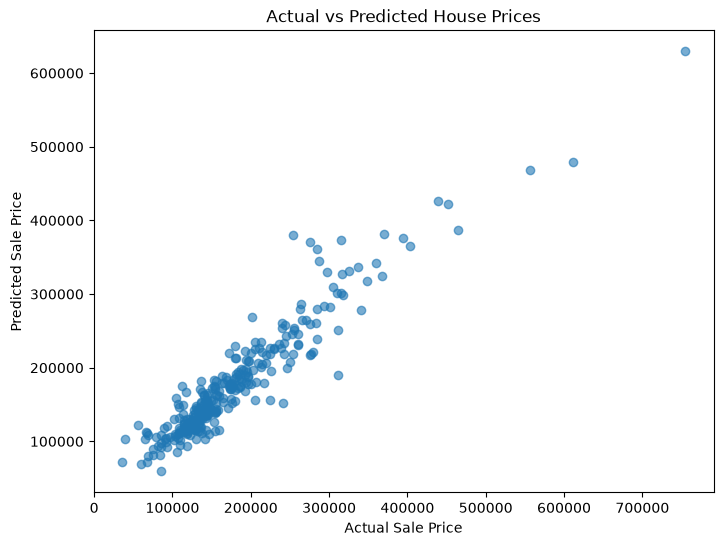

In [13]:
# Plot actual vs predicted house prices

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

# Part 2: K-Means Clustering

## Introduction

Clustering is an unsupervised machine learning technique used to discover natural groups within data.

For this task, the Mall Customers dataset is used with the K-Means clustering algorithm.

The goal is to identify groups of customers based on their age, annual income, and spending score.

In [14]:
# Load the Mall Customers dataset

customer_df = pd.read_csv("Mall_Customers.csv")

print("Dataset loaded successfully!")
print("Shape:", customer_df.shape)

customer_df.head()

Dataset loaded successfully!
Shape: (200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [15]:
# Display information about the customer dataset

customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [16]:
# Check missing values and duplicate rows

print("Missing values:")
print(customer_df.isnull().sum())

print("\nDuplicate rows:", customer_df.duplicated().sum())

Missing values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


In [17]:
# Select numerical features for clustering

cluster_features = [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]

X_cluster = customer_df[cluster_features]

print("Selected clustering features:")
print(cluster_features)

X_cluster.head()

Selected clustering features:
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [18]:
# Standardize the clustering features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

print("Data standardized successfully!")
print("Scaled data shape:", X_scaled.shape)

Data standardized successfully!
Scaled data shape: (200, 3)


In [19]:
# Calculate inertia for different numbers of clusters

inertias = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

print("Inertia values:")
for k, inertia in zip(range(1, 11), inertias):
    print(f"K = {k}: {inertia:.2f}")

Inertia values:
K = 1: 600.00
K = 2: 389.39
K = 3: 295.21
K = 4: 205.23
K = 5: 168.25
K = 6: 133.87
K = 7: 117.01
K = 8: 103.87
K = 9: 93.09
K = 10: 82.39


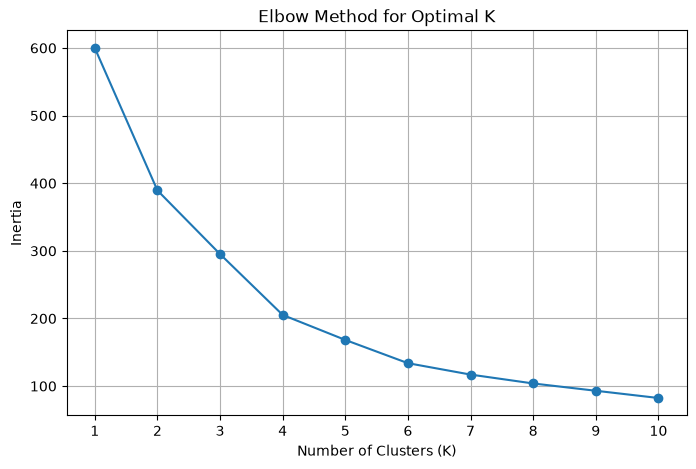

In [20]:
# Plot the Elbow Method curve

plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), inertias, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

In [21]:
# Create the final K-Means model with 4 clusters

chosen_k = 4

kmeans = KMeans(
    n_clusters=chosen_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataset
customer_df['Cluster'] = cluster_labels

print("K-Means clustering completed successfully!")
print("Number of clusters:", chosen_k)

K-Means clustering completed successfully!
Number of clusters: 4


In [22]:
# Count the number of customers in each cluster

cluster_counts = customer_df['Cluster'].value_counts().sort_index()

print("Number of customers in each cluster:")
print(cluster_counts)

Number of customers in each cluster:
Cluster
0    65
1    40
2    57
3    38
Name: count, dtype: int64


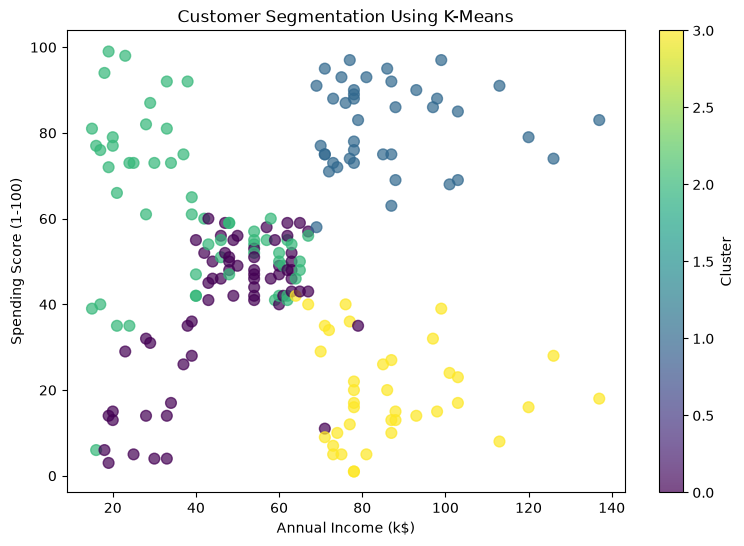

In [23]:
# Visualize the customer clusters

plt.figure(figsize=(9, 6))

plt.scatter(
    customer_df['Annual Income (k$)'],
    customer_df['Spending Score (1-100)'],
    c=customer_df['Cluster'],
    s=60,
    alpha=0.7
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation Using K-Means')
plt.colorbar(label='Cluster')

plt.show()

In [24]:
# Calculate the average characteristics of each cluster

cluster_summary = customer_df.groupby('Cluster')[cluster_features].mean().round(2)

print("Cluster Characteristics:")
cluster_summary

Cluster Characteristics:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,53.98,47.71,39.97
1,32.88,86.10,81.53
2,25.44,40.00,60.30
3,39.37,86.50,19.58


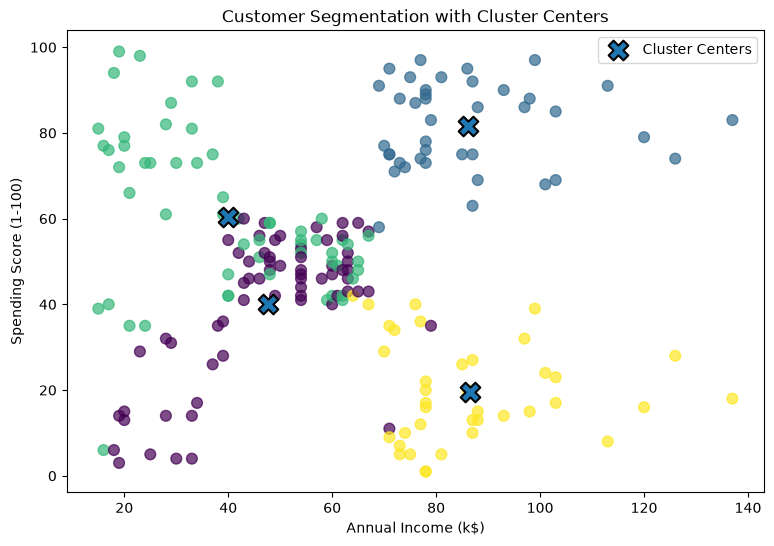

In [25]:
# Visualize clusters and their centroids

plt.figure(figsize=(9, 6))

plt.scatter(
    customer_df['Annual Income (k$)'],
    customer_df['Spending Score (1-100)'],
    c=customer_df['Cluster'],
    s=60,
    alpha=0.7
)

# Convert scaled cluster centers back to original scale
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:, 1],
    centers[:, 2],
    marker='X',
    s=200,
    edgecolors='black',
    linewidths=1.5,
    label='Cluster Centers'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation with Cluster Centers')
plt.legend()

plt.show()

# 17. Conclusion

This project demonstrated two different machine learning approaches: supervised regression and unsupervised clustering.

For the regression task, a Random Forest Regressor was trained using selected house-related features to predict `SalePrice`. The model was evaluated using RMSE and R² score.

The regression model achieved an RMSE of approximately 29,016.77 and an R² score of approximately 0.8902. This indicates that the selected features provided useful information for predicting house sale prices.

For the clustering task, the Mall Customers dataset was analyzed using K-Means clustering. The features Age, Annual Income, and Spending Score were standardized before applying K-Means.

The Elbow Method was used to determine a reasonable number of clusters. Based on the elbow curve, 4 clusters were selected.

The resulting clusters reveal different customer characteristics based on age, income, and spending behavior. This demonstrates how clustering can be used for customer segmentation and discovering hidden patterns in real-world data.

Overall, this project provided practical experience with both supervised and unsupervised machine learning techniques.